In [2]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [5]:
# Load Dataset
data = pd.read_csv("WineQT.csv")
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [6]:
print(data['quality'])

0       5
1       5
2       5
3       6
4       5
       ..
1138    6
1139    6
1140    5
1141    6
1142    5
Name: quality, Length: 1143, dtype: int64


In [7]:
# Convert to Binary
data['quality'] = data['quality'].apply(lambda x: 1 if x >= 5 else 0)
X = data.drop("quality", axis=1)
y = data["quality"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [8]:
# Parameter Grid
param_grid = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

results = {}
times = {}

model = DecisionTreeClassifier(random_state=42)


In [9]:
# Grid Search
start = time.time()
grid = GridSearchCV(model, param_grid, cv=5)
grid.fit(X_train, y_train)
end = time.time()

y_pred = grid.predict(X_test)

results["Grid"] = accuracy_score(y_test, y_pred)
times["Grid"] = end - start


In [10]:
# Random Search
start = time.time()
random = RandomizedSearchCV(model, param_grid, cv=5, n_iter=10, random_state=42)
random.fit(X_train, y_train)
end = time.time()

y_pred = random.predict(X_test)

results["Random"] = accuracy_score(y_test, y_pred)
times["Random"] = end - start



In [11]:
# Successive Halving
start = time.time()
halving = HalvingGridSearchCV(model, param_grid, cv=5)
halving.fit(X_train, y_train)
end = time.time()

y_pred = halving.predict(X_test)

results["Halving"] = accuracy_score(y_test, y_pred)
times["Halving"] = end - start

In [12]:
# Print Results
print("Decision Tree Results")
print(results)
print("Time Taken")
print(times)


Decision Tree Results
{'Grid': 0.9432314410480349, 'Random': 0.9432314410480349, 'Halving': 0.9475982532751092}
Time Taken
{'Grid': 2.000253200531006, 'Random': 0.8240740299224854, 'Halving': 2.3351004123687744}


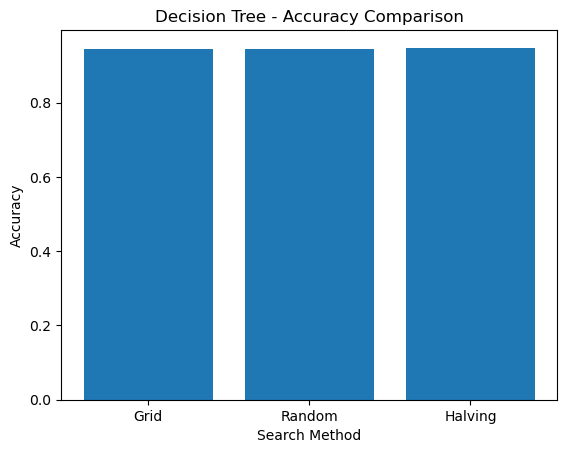

In [13]:
# Plot Accuracy Graph
plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Decision Tree - Accuracy Comparison")
plt.xlabel("Search Method")
plt.ylabel("Accuracy")
plt.show()

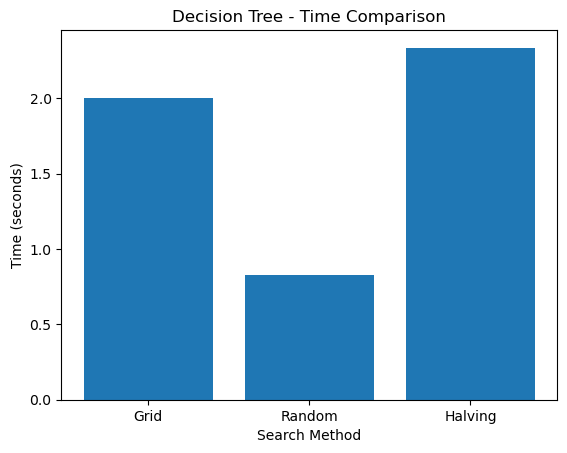

In [14]:
# Plot Time Graph
plt.figure()
plt.bar(times.keys(), times.values())
plt.title("Decision Tree - Time Comparison")
plt.xlabel("Search Method")
plt.ylabel("Time (seconds)")
plt.show()